In [2]:
!pip install kagglehub -q

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os
import zipfile
from datetime import datetime
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

In [3]:
path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")

print("✅ Dataset Download সম্পন্ন!")
print(f"📁 Path: {path}")
print(f"\n📋 Files:")

# সব file দেখা
for f in os.listdir(path):
    print(f"   {f}")

Using Colab cache for faster access to the 'heart-disease-dataset' dataset.
✅ Dataset Download সম্পন্ন!
📁 Path: /kaggle/input/heart-disease-dataset

📋 Files:
   heart.csv


In [4]:
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(f"✅ File Loaded: {csv_file}")
print(f"📊 Shape: {df.shape}")
print(f"\n🔍 প্রথম ৫ Row:")
display(df.head())

print(f"\n🔍 Column Names:")
print(df.columns.tolist())

✅ File Loaded: heart.csv
📊 Shape: (1025, 14)

🔍 প্রথম ৫ Row:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



🔍 Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [5]:
print(df.isnull().sum())

if df.isnull().sum().sum() == 0:
    print("✅ কোনো Missing Value নেই!")

# Duplicates
dup = df.duplicated().sum()
print(f"\n🔍 Duplicate Rows: {dup}")
if dup > 0:
    df.drop_duplicates(inplace=True)
    print(f"✅ {dup}টি Duplicate মুছে ফেলা হয়েছে!")
else:
    print("✅ কোনো Duplicate নেই!")

# Statistical Summary
print("\n🔍 Statistical Summary:")
display(df.describe())

# Outlier Check
print("\n🔍 Outlier Check (IQR Method):")
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    out = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"   {col}: {out} outlier(s)")

# Cholesterol = 0 fix
if (df['chol'] == 0).sum() > 0:
    df['chol'].replace(0, df['chol'].median(), inplace=True)
    print("\n✅ Cholesterol এর 0 value fix হয়েছে!")

print(f"\n✅ Cleaning সম্পন্ন! Final Shape: {df.shape}")

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
✅ কোনো Missing Value নেই!

🔍 Duplicate Rows: 723
✅ 723টি Duplicate মুছে ফেলা হয়েছে!

🔍 Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000



🔍 Outlier Check (IQR Method):
   age: 0 outlier(s)
   trestbps: 9 outlier(s)
   chol: 5 outlier(s)
   thalach: 1 outlier(s)
   oldpeak: 5 outlier(s)

✅ Cleaning সম্পন্ন! Final Shape: (302, 14)


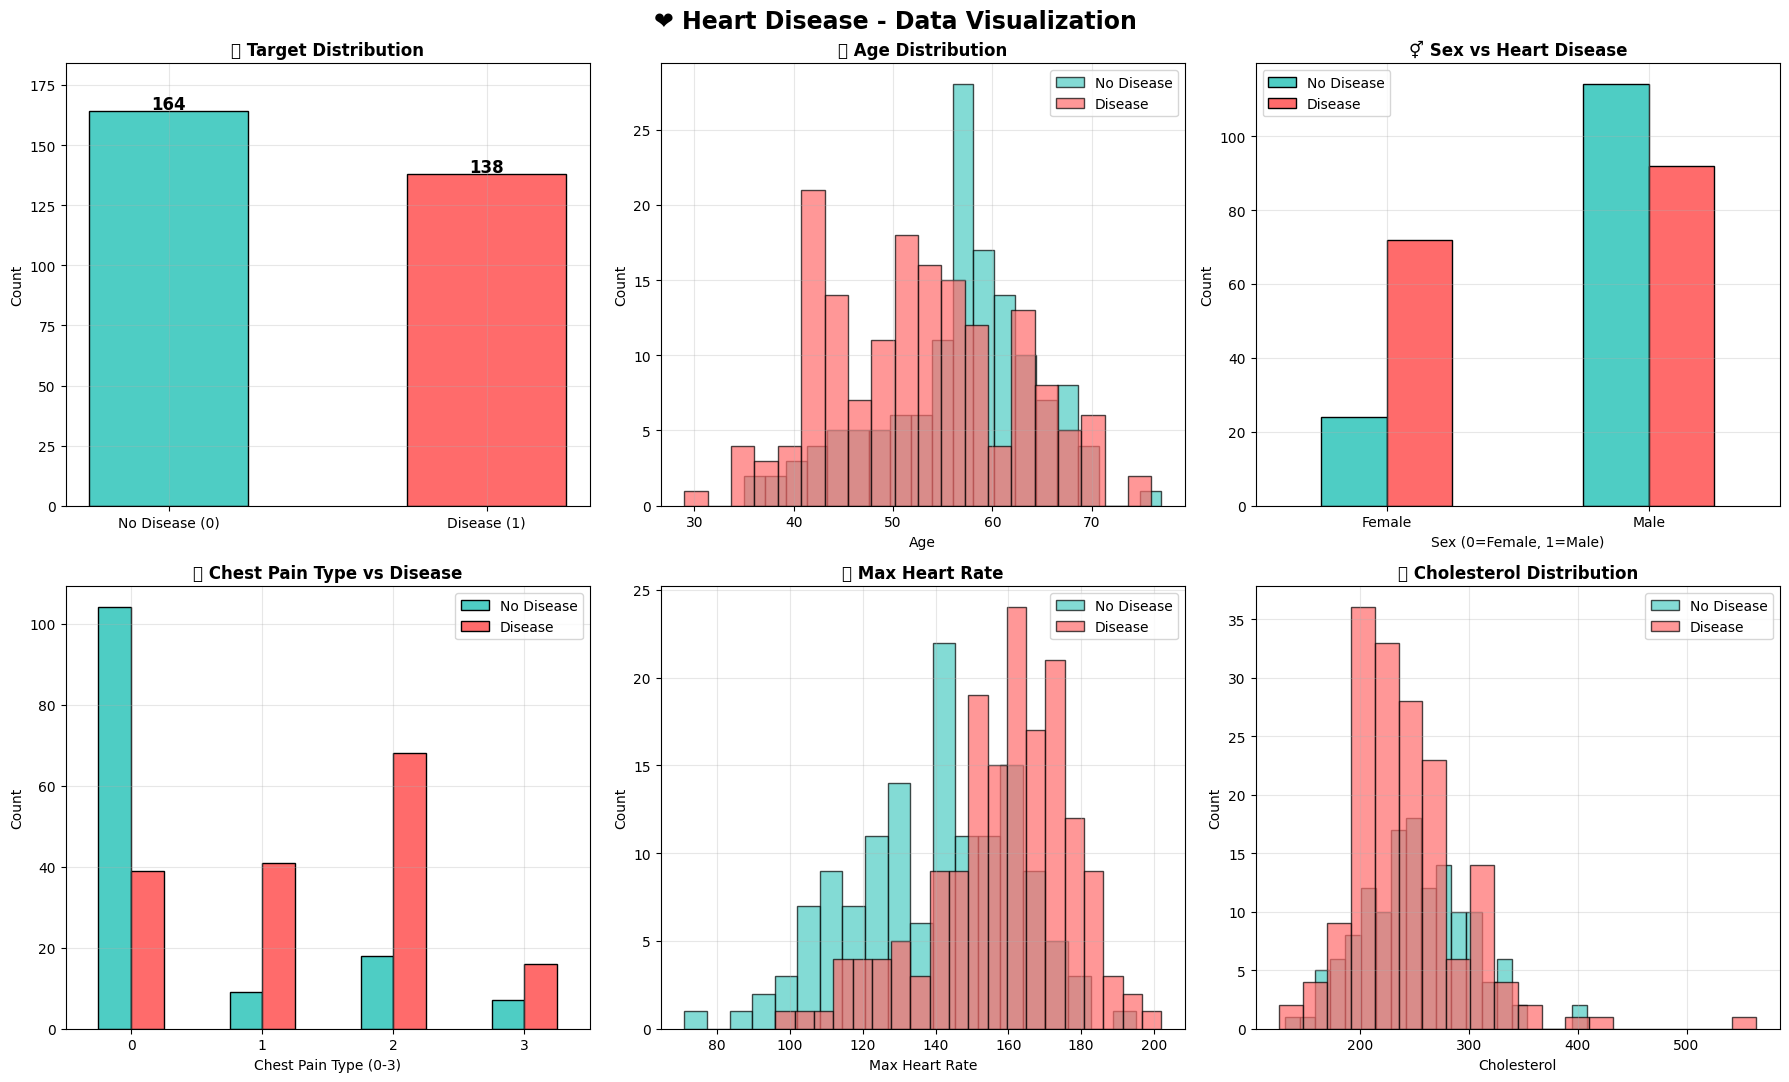

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('❤️ Heart Disease - Data Visualization',
             fontsize=17, fontweight='bold')

# 1. Target Distribution
ax = axes[0, 0]
counts = df['target'].value_counts()
bars = ax.bar(['No Disease (0)', 'Disease (1)'], counts.values,
              color=['#4ECDC4', '#FF6B6B'], edgecolor='black', width=0.5)
ax.set_title('🎯 Target Distribution', fontweight='bold')
ax.set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1, str(val),
            ha='center', fontweight='bold', fontsize=12)
ax.set_ylim(0, max(counts.values) + 20)
ax.grid(True, alpha=0.3)

# 2. Age Distribution
ax = axes[0, 1]
ax.hist(df[df['target']==0]['age'], bins=20, alpha=0.7,
        color='#4ECDC4', label='No Disease', edgecolor='black')
ax.hist(df[df['target']==1]['age'], bins=20, alpha=0.7,
        color='#FF6B6B', label='Disease', edgecolor='black')
ax.set_title('👤 Age Distribution', fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Sex vs Target
ax = axes[0, 2]
sex_target = df.groupby(['sex', 'target']).size().unstack()
sex_target.plot(kind='bar', ax=ax,
                color=['#4ECDC4', '#FF6B6B'],
                edgecolor='black')
ax.set_title('⚥ Sex vs Heart Disease', fontweight='bold')
ax.set_xlabel('Sex (0=Female, 1=Male)')
ax.set_ylabel('Count')
ax.set_xticklabels(['Female', 'Male'], rotation=0)
ax.legend(['No Disease', 'Disease'])
ax.grid(True, alpha=0.3)

# 4. Chest Pain Type
ax = axes[1, 0]
cp_target = df.groupby(['cp', 'target']).size().unstack()
cp_target.plot(kind='bar', ax=ax,
               color=['#4ECDC4', '#FF6B6B'],
               edgecolor='black')
ax.set_title('💔 Chest Pain Type vs Disease', fontweight='bold')
ax.set_xlabel('Chest Pain Type (0-3)')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(['No Disease', 'Disease'])
ax.grid(True, alpha=0.3)

# 5. Max Heart Rate
ax = axes[1, 1]
ax.hist(df[df['target']==0]['thalach'], bins=20, alpha=0.7,
        color='#4ECDC4', label='No Disease', edgecolor='black')
ax.hist(df[df['target']==1]['thalach'], bins=20, alpha=0.7,
        color='#FF6B6B', label='Disease', edgecolor='black')
ax.set_title('💓 Max Heart Rate', fontweight='bold')
ax.set_xlabel('Max Heart Rate')
ax.set_ylabel('Count')
ax.legend()
ax.grid(True, alpha=0.3)

# 6. Cholesterol
ax = axes[1, 2]
ax.hist(df[df['target']==0]['chol'], bins=20, alpha=0.7,
        color='#4ECDC4', label='No Disease', edgecolor='black')
ax.hist(df[df['target']==1]['chol'], bins=20, alpha=0.7,
        color='#FF6B6B', label='Disease', edgecolor='black')
ax.set_title('🩸 Cholesterol Distribution', fontweight='bold')
ax.set_xlabel('Cholesterol')
ax.set_ylabel('Count')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('viz_basic.png', dpi=150, bbox_inches='tight')
plt.show()

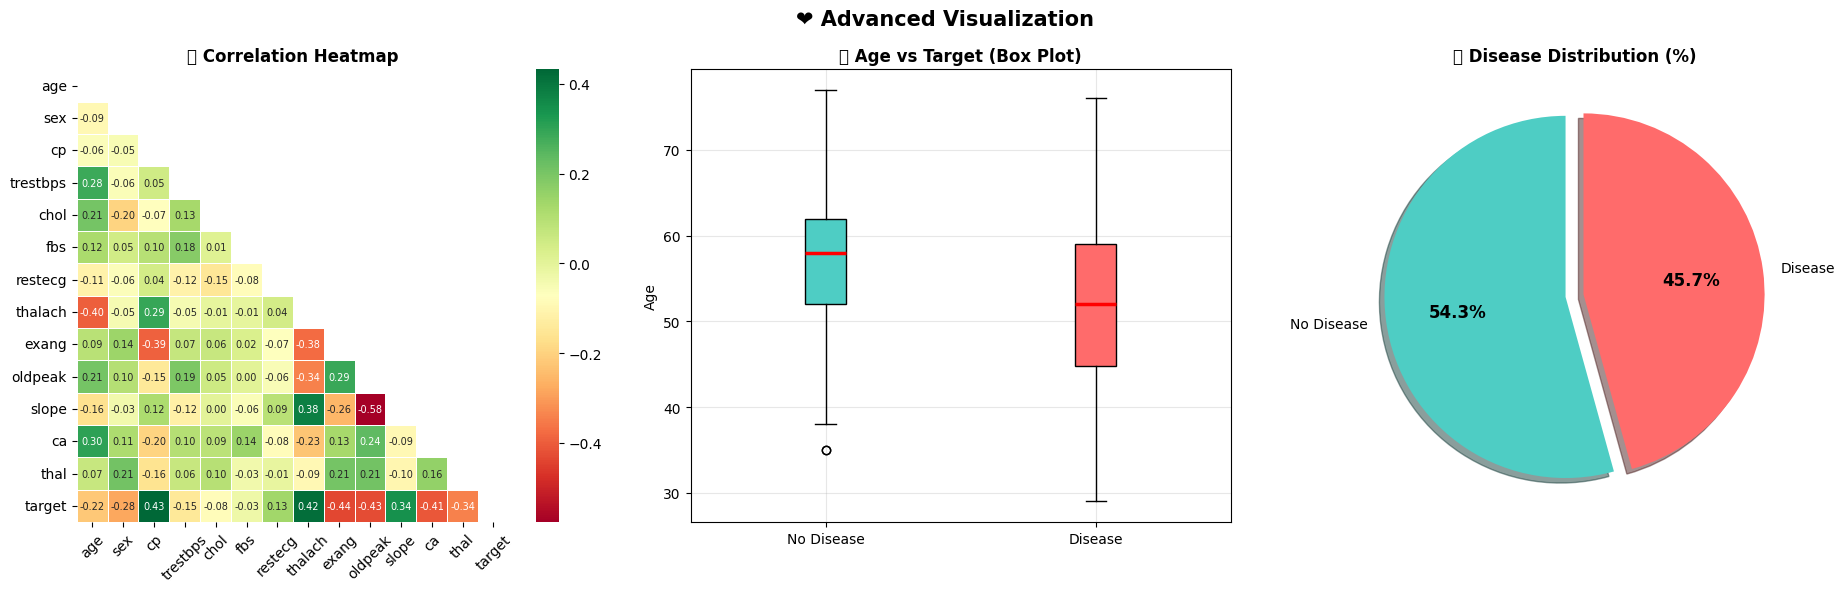

📊 Pairplot তৈরি হচ্ছে...


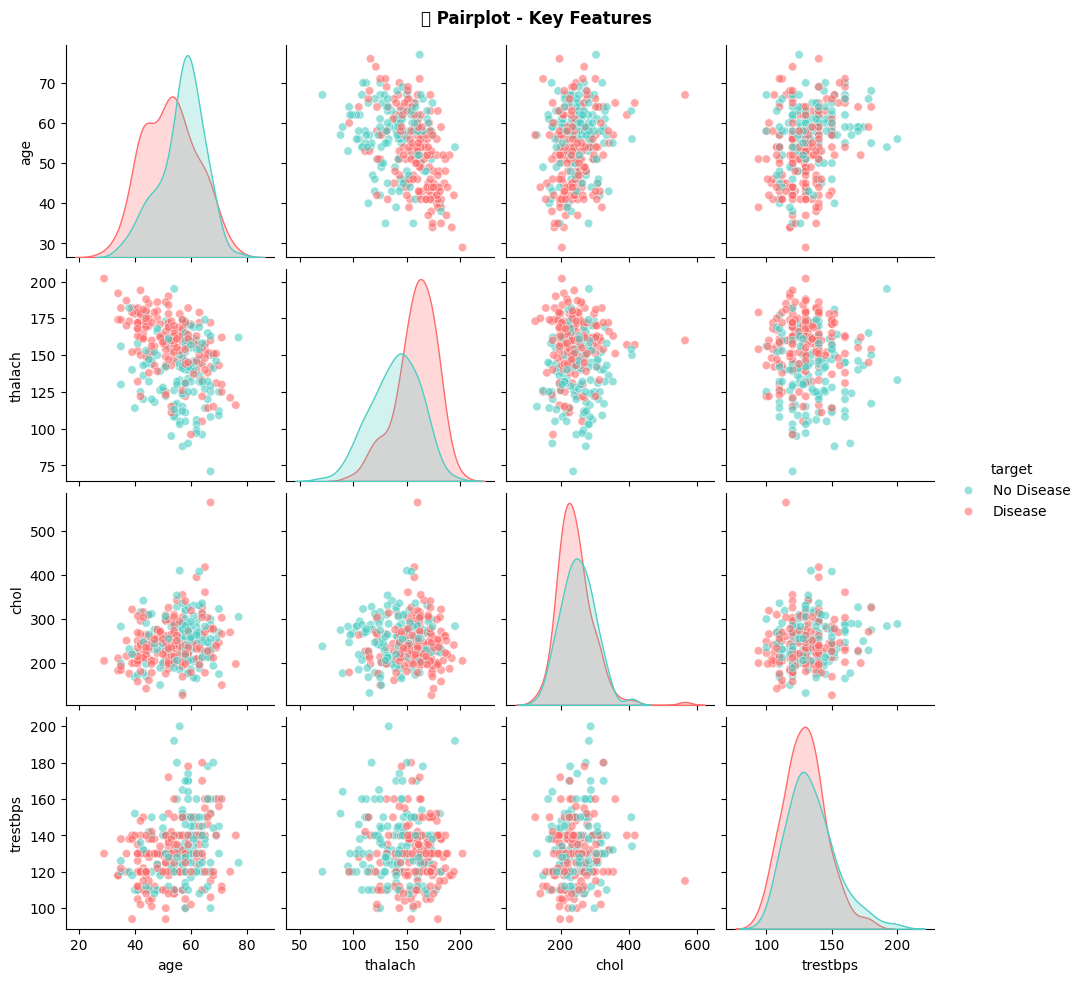

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle('❤️ Advanced Visualization', fontsize=15, fontweight='bold')

# 1. Correlation Heatmap
ax = axes[0]
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=ax, linewidths=0.5,
            annot_kws={"size": 7}, mask=mask)
ax.set_title('🔥 Correlation Heatmap', fontweight='bold')
ax.tick_params(axis='x', rotation=45)

# 2. Box Plot
ax = axes[1]
bp = ax.boxplot([df[df['target']==0]['age'],
                 df[df['target']==1]['age']],
                labels=['No Disease', 'Disease'],
                patch_artist=True,
                medianprops=dict(color='red', linewidth=2.5))
bp['boxes'][0].set_facecolor('#4ECDC4')
bp['boxes'][1].set_facecolor('#FF6B6B')
ax.set_title('📦 Age vs Target (Box Plot)', fontweight='bold')
ax.set_ylabel('Age')
ax.grid(True, alpha=0.3)

# 3. Pie Chart
ax = axes[2]
counts = df['target'].value_counts()
wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=['No Disease', 'Disease'],
    autopct='%1.1f%%',
    colors=['#4ECDC4', '#FF6B6B'],
    startangle=90,
    explode=(0.05, 0.05),
    shadow=True
)
for t in autotexts:
    t.set_fontweight('bold')
    t.set_fontsize(12)
ax.set_title('🥧 Disease Distribution (%)', fontweight='bold')

plt.tight_layout()
plt.savefig('viz_advanced.png', dpi=150, bbox_inches='tight')
plt.show()

# Pairplot
print("📊 Pairplot তৈরি হচ্ছে...")
pair_df = df[['age', 'thalach', 'chol', 'trestbps', 'target']].copy()
pair_df['target'] = pair_df['target'].map({0:'No Disease', 1:'Disease'})
g = sns.pairplot(pair_df, hue='target',
                 palette={'No Disease':'#4ECDC4', 'Disease':'#FF6B6B'},
                 plot_kws={'alpha': 0.6}, height=2.4)
g.fig.suptitle('🔍 Pairplot - Key Features', y=1.02, fontweight='bold')
plt.savefig('pairplot.png', dpi=100, bbox_inches='tight')
plt.show()

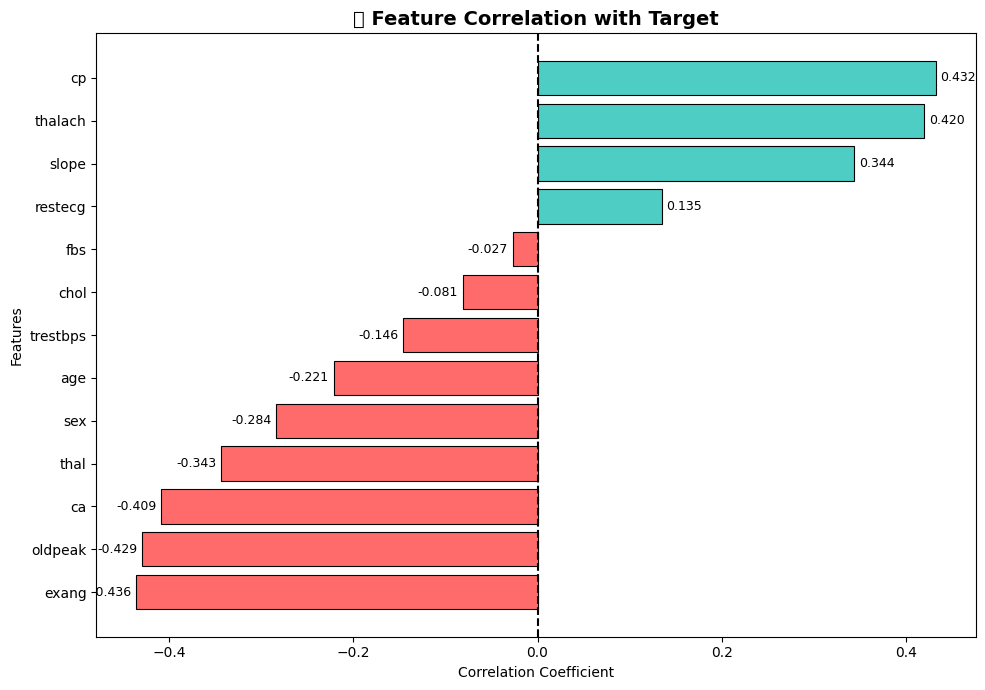

In [8]:
corr_target = df.corr()['target'].drop('target').sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = ['#FF6B6B' if x < 0 else '#4ECDC4' for x in corr_target.values]
bars = plt.barh(corr_target.index, corr_target.values,
                color=colors, edgecolor='black', linewidth=0.8)
plt.axvline(x=0, color='black', linewidth=1.5, linestyle='--')
plt.title('📊 Feature Correlation with Target',
          fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
for bar, val in zip(bars, corr_target.values):
    plt.text(val + (0.005 if val >= 0 else -0.005),
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center',
             ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig('feature_corr.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
X = df.drop('target', axis=1)
y = df['target']
print(f"\n✅ Features (X) : {X.shape}")
print(f"✅ Target   (y) : {y.shape}")

# One-Hot Encoding
cat_cols = ['cp', 'restecg', 'slope', 'thal']
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(f"\n✅ One-Hot Encoding পরে : {X.shape}")

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n✅ Train : {X_train.shape}")
print(f"✅ Test  : {X_test.shape}")

# Standard Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

input_dim = X_train_sc.shape[1]
print(f"\n✅ Scaling সম্পন্ন!")
print(f"✅ Input Dimension: {input_dim}")


✅ Features (X) : (302, 13)
✅ Target   (y) : (302,)

✅ One-Hot Encoding পরে : (302, 19)

✅ Train : (241, 19)
✅ Test  : (61, 19)

✅ Scaling সম্পন্ন!
✅ Input Dimension: 19


In [10]:
model = Sequential([
    Dense(64, input_dim=input_dim, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 192 (768.00 B)

In [11]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=0)
]

history = model.fit(
    X_train_sc, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print(f"\n✅ Training সম্পন্ন!")
print(f"   Epochs        : {len(history.history['loss'])}")
print(f"   Best Val Acc  : {max(history.history['val_accuracy'])*100:.2f}%")

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5895 - loss: 0.7679 

6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 350ms/step - accuracy: 0.6198 - loss: 0.7248 - val_accuracy: 0.6531 - val_loss: 0.6365
Epoch 2/100
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.6562 - loss: 0.5485

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6875 - loss: 0.5870 - val_accuracy: 0.7551 - val_loss: 0.6163
Epoch 3/100
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6562 - loss: 0.6212

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7083 - loss: 0.5593 - val_accuracy: 0.7755 - val_loss: 0.5974
Epoch 4/100
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7500 - loss: 0.6090

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7448 - loss: 0.5830 - val_accuracy: 0.8367 - val_loss: 0.5805
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7656 - loss: 0.5266 - val_accuracy: 0.8367 - val_loss: 0.5648
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7708 - loss: 0.4843 - val_accuracy: 0.8367 - val_loss: 0.5494
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7656 - loss: 0.4866 - val_accuracy: 0.8367 - val_loss: 0.5367
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8021 - loss: 0.4727 - val_accuracy: 0.8163 - val_loss: 0.5228
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7969 - loss: 0.4379 - val_accuracy: 0.8163 - val_loss: 0.5109
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8229 - loss: 0.4336 - val_accuracy: 0.8163 - val_loss: 0.4998
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8125 - loss: 0.4271 - val_accuracy: 0.8163 - val_loss: 0.4902
Ep

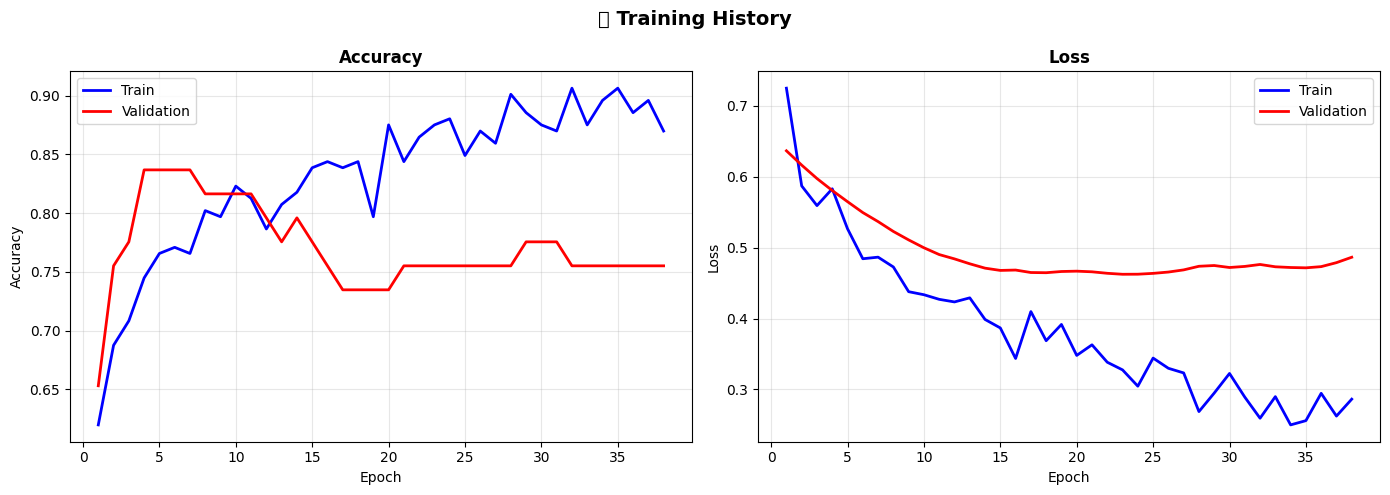

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📈 Training History', fontsize=14, fontweight='bold')

ep = range(1, len(history.history['loss']) + 1)

ax1.plot(ep, history.history['accuracy'],     'b-', lw=2, label='Train')
ax1.plot(ep, history.history['val_accuracy'], 'r-', lw=2, label='Validation')
ax1.set_title('Accuracy', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(ep, history.history['loss'],     'b-', lw=2, label='Train')
ax2.plot(ep, history.history['val_loss'], 'r-', lw=2, label='Validation')
ax2.set_title('Loss', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
y_pred_prob = model.predict(X_test_sc)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

train_loss, train_acc = model.evaluate(X_train_sc, y_train, verbose=0)
test_loss,  test_acc  = model.evaluate(X_test_sc,  y_test,  verbose=0)

print(f"📊 Train Accuracy : {train_acc*100:.2f}%")
print(f"📊 Test  Accuracy : {test_acc*100:.2f}%")
print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['No Disease', 'Disease']))

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
print(f"📈 ROC-AUC: {roc_auc:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 908ms/step
📊 Train Accuracy : 85.48%
📊 Test  Accuracy : 81.97%

📋 Classification Report:
              precision    recall  f1-score   support

  No Disease       0.79      0.82      0.81        28
     Disease       0.84      0.82      0.83        33

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61

📈 ROC-AUC: 0.8701


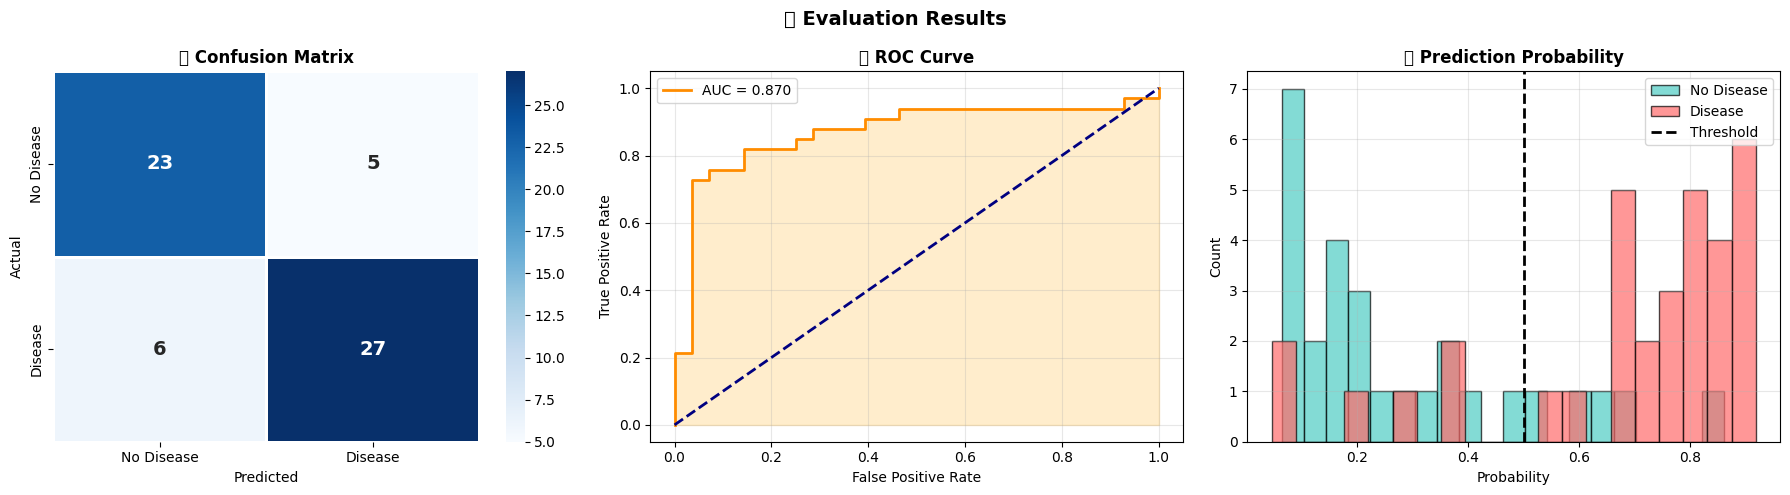

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('🎯 Evaluation Results', fontsize=14, fontweight='bold')

# Confusion Matrix
ax = axes[0]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            linewidths=2, linecolor='white',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'],
            annot_kws={"size": 14, "weight": "bold"})
ax.set_title('🔲 Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

# ROC Curve
ax = axes[1]
ax.plot(fpr, tpr, color='darkorange', lw=2,
        label=f'AUC = {roc_auc:.3f}')
ax.plot([0, 1], [0, 1], 'navy', lw=2, linestyle='--')
ax.fill_between(fpr, tpr, alpha=0.2, color='orange')
ax.set_title('📈 ROC Curve', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
ax.grid(True, alpha=0.3)

# Prediction Distribution
ax = axes[2]
ax.hist(y_pred_prob[y_test==0], bins=20, alpha=0.7,
        color='#4ECDC4', label='No Disease', edgecolor='black')
ax.hist(y_pred_prob[y_test==1], bins=20, alpha=0.7,
        color='#FF6B6B', label='Disease', edgecolor='black')
ax.axvline(x=0.5, color='black', linestyle='--', lw=2, label='Threshold')
ax.set_title('📊 Prediction Probability', fontweight='bold')
ax.set_xlabel('Probability')
ax.set_ylabel('Count')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Model Save
model.save('ann_heart_disease_model.h5')

# Scaler Save
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Info Save
info = {
    'input_dim'     : input_dim,
    'features'      : X.columns.tolist(),
    'test_accuracy' : round(float(test_acc), 4),
    'roc_auc'       : round(float(roc_auc), 4),
    'saved_date'    : datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}
with open('model_info.pkl', 'wb') as f:
    pickle.dump(info, f)

# ZIP
zip_name = 'ANN_Heart_Disease_Model.zip'
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in ['ann_heart_disease_model.h5', 'best_model.h5',
                  'scaler.pkl', 'model_info.pkl',
                  'viz_basic.png', 'viz_advanced.png',
                  'pairplot.png', 'feature_corr.png',
                  'training_history.png', 'evaluation.png']:
        if os.path.exists(fname):
            zf.write(fname)

print(f"✅ ZIP তৈরি: {zip_name}")
print(f"📦 Size: {os.path.getsize(zip_name)/1024:.2f} KB")

# Download
from google.colab import files
files.download(zip_name)

✅ ZIP তৈরি: ANN_Heart_Disease_Model.zip
📦 Size: 985.83 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
print(f"  📊 Dataset        : Heart Disease (Kaggle)")
print(f"  📋 Shape          : {df.shape[0]} rows × {df.shape[1]} cols")
print(f"  🧠 Model          : ANN")
print(f"  📐 Architecture   : {input_dim} → 64 → 32 → 16 → 1")
print(f"  🏋️  Epochs         : {len(history.history['loss'])}")
print(f"  ✅ Train Accuracy  : {train_acc*100:.2f}%")
print(f"  ✅ Test  Accuracy  : {test_acc*100:.2f}%")
print(f"  📈 ROC-AUC        : {roc_auc:.4f}")
print(f"  💾 Downloaded     : {zip_name}")

  📊 Dataset        : Heart Disease (Kaggle)
  📋 Shape          : 302 rows × 14 cols
  🧠 Model          : ANN
  📐 Architecture   : 19 → 64 → 32 → 16 → 1
  🏋️  Epochs         : 38
  ✅ Train Accuracy  : 85.48%
  ✅ Test  Accuracy  : 81.97%
  📈 ROC-AUC        : 0.8701
  💾 Downloaded     : ANN_Heart_Disease_Model.zip
